<a href="https://colab.research.google.com/github/sincanmaulanaa/dicoding-machine-learning-development-exercises/blob/main/dicoding_submission_nlp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



```
# Ini diformat sebagai kode
```

# NLP for MLBB review on playstore Multiclass Categorization


In [1]:
!pip install google-play-scraper

from google_play_scraper import app, reviews, Sort, reviews_all

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 2.5 MB/s eta 0:00:00


In [2]:
import pandas as pd # Pandas untuk manipulasi dan analisis data
pd.options.mode.chained_assignment = None # Menonaktifkan peringatan chaining

import numpy as np # NumPy untuk komputasi numerik
seed = 0
np.random.seed(seed) # Mengatur seed untuk reproduktibilitas

In [3]:
# Mengambil semua ulasan dari aplikasi dengan ID 'com.mobile.legends' di Google Play Store.
# Proses scraping mungkin memerlukan beberapa saat tergantung pada jumlah ulasan yang ada.
scrapereview = reviews_all(
    'com.mobile.legends', # ID Aplikasi
    lang='id', # bahasa ulasan, default 'en'
    country='id', # negara, default 'us'
    sort=Sort.MOST_RELEVANT, # urutan ulasan, default Sort.MOST_RELEVANT
    count=5000 # jumlah maksimum ulasan yang ingin diambil
)


# Menyimpan ulasan dalam file CSV
import csv


In [4]:

with open('ulasan_mlbb.csv', mode='w', newline='', encoding='utf-8') as file:
  writer = csv.writer(file)
  writer.writerow(['Review']) # menulis header kolom
  for review in scrapereview:
    writer.writerow([review['content']]) # menulis konten ulasan ke dalam file CSV


# meload dataset
df = pd.DataFrame(scrapereview)
df.shape
df.to_csv('ulasan_mlbb.csv', index=False)

# membuat dataframe dari hasil scrapereview
df = pd.DataFrame(scrapereview)

## Load dataset


In [5]:
df.head(10)

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,e190bbc4-c9a0-4d18-8156-50e8a69f2366,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Biar ku perjelas, Kendala atau hal yang paling...",1,2258,19.2.21.104,2024-11-15 09:55:57,None,NaT,19.2.21.104
1,d11d2c3c-3e24-45e2-9f42-851c25e071fc,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Makin kesini makin buruk gamenya,mulai dari da...",1,42651,19.2.21.104,2024-11-10 13:26:55,None,NaT,19.2.21.104
2,37f5cd33-479f-48e7-b0ba-2c135216b86f,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Saya mohon untuk match nya diperbaiki, untuk j...",1,567,19.2.21.104,2024-11-11 01:10:30,"Halo Kak,\nMaaf atas masalah jaringan yang Kak...",2024-11-11 04:01:18,19.2.21.104
3,76aeed7b-53ab-4006-9568-d49abf5948fc,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Untuk gamenya sudah bagus ya, tapi untuk beber...",1,4550,1.9.29.10113,2024-11-13 13:03:01,None,NaT,1.9.29.10113
4,f6fb0d12-c1d6-4178-b4ea-5c7e76296fa9,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Game bagus dan keren, suatu kendala dari game ...",1,4957,1.9.32.10116,2024-11-12 07:41:58,"Halo Kak,\nTerima kasih atas feedback-nya.\nKa...",2024-11-12 09:47:07,1.9.32.10116
5,a041ecd7-8baf-47cd-a599-b69b1f17f222,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Tolong Perbaiki lagi sistemnya,tidak classic t...",1,20603,1.9.29.10113,2024-11-13 13:12:53,None,NaT,1.9.29.10113
6,d8b23c42-8148-4808-bced-cf74dc63cc8f,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Setelah update kenapa lag trus, padahal sinyal...",1,1893,1.9.32.10116,2024-11-11 16:21:39,None,NaT,1.9.32.10116
7,542c110f-1fe7-4126-a7e2-f960edad898f,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Saya kasi bintang 2 aja, karena apa? Ya karena...",2,2062,1.9.29.10113,2024-11-13 06:54:31,None,NaT,1.9.29.10113
8,0422e1ac-a147-41fb-82ec-e7544aecf4b1,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Untuk moonton saya kesal dan tidak suka dengan...,2,1452,1.9.29.10113,2024-11-11 11:13:12,None,NaT,1.9.29.10113
9,32fff8c0-e93a-48bb-8074-0b7a06727a61,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Bagus sih tapi cuman ada satu kendala yaitu pa...,5,19410,1.9.29.10113,2024-11-09 11:42:00,None,NaT,1.9.29.10113


In [6]:
# data columns
df.columns

Index(['reviewId', 'userName', 'userImage', 'content', 'score',
       'thumbsUpCount', 'reviewCreatedVersion', 'at', 'replyContent',
       'repliedAt', 'appVersion'],
      dtype='object')

In [7]:
# total data
df.shape

(108000, 11)

In [8]:
# data info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 108000 entries, 0 to 107999
Data columns (total 11 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   reviewId              108000 non-null  object        
 1   userName              108000 non-null  object        
 2   userImage             108000 non-null  object        
 3   content               108000 non-null  object        
 4   score                 108000 non-null  int64         
 5   thumbsUpCount         108000 non-null  int64         
 6   reviewCreatedVersion  90628 non-null   object        
 7   at                    108000 non-null  datetime64[ns]
 8   replyContent          4103 non-null    object        
 9   repliedAt             4103 non-null    datetime64[ns]
 10  appVersion            90628 non-null   object        
dtypes: datetime64[ns](2), int64(2), object(7)
memory usage: 9.1+ MB


In [9]:
# categories
df.content.value_counts()

,count
content,
Bagus tapi banyak dark sistem,5
"Saya kurang suka dengan Garfiknya yang sekarang,sangat tidak nyaman, saya lebih nyaman dengan grafik yang dulu, makin lama makin ga bagus ini mobile legend, update baru kali ini paling terparah!!!!! 2016 saya main game mobile legends, baru ini saya kecewa dengan melihat tampilan mobile legends tolong kembalikan mobile legends, bisa² player lain hapus game mobile legends karna banyk yang kecewa tolong kembalikan yang kemarin² seblm kebnykn player² lain menghapus game ml",3
"Setelah pembaruan makin tolol ajaa grafik kaya game bocah banget makin aneh, kenapa item jungle gk bisa di beli dan size untuk penyimpanannya sekarang sampai 8GB, dan sering LAG dan patah"" padalhan RAM HP Saya 6GB, mohon perubahannya seperti versi yang lama ajaa, sebelum semua orang males maen mobile legend dan perpindah ke game lain. terima kasih.",3
"untuk moonton,kami harap untuk memperbaiki sistem auto battle pada hero yang afk agar tidak menyerang minion menggunakan ulty & menerobos turret lawan.Dan untuk sistem win rate diganti dengan nilai ranting di akhir permainan agar lebih adil kepada pemain mvp yang kalah.agar pemain tetap menikmati kemenangan maupun kekalahan nya,kami mohon keinginan kami bisa dipertimbangkan .terima kasih sudah mau membaca saran kami.",3
Grafiknya sangat bagus,3
...,...
"Tolong dong, kenapa setelah update 515 ini kalo main sinyal pasti lag, ping pasti tinggi, jadi malas maen ni game, padahal provider bagus hp juga bagus, tolong masalah sinyal lag di perhatikan, jangan hanya update hero baru terus !!!!",1
"Bagaimana lah moontoon, saya tau lah kalian bekerja keras demi mewujudkan yang terbaik, tapi barusan saya rank malah nggak bisa untuk ban, terhentikan beberapa menit, dan akhirnya semua hero pun lolos, jadilah kekalahan yang nggak etis karena masalah ban yang terhentikan selama beberapa menit, kalo ulasan ini bisa d kasih foto, banyak kali aku udah screen shoot ttg semua bug ato apalah itu, apakah itu krna pembaruan ini atau bukan? , banyak pemain moba yang meng uninstal game ini krn itu",1
main mobile legend sekarang jadi malas sudah ngga bukak aplikasi ini lagi karena lag padahal udah pake wifi cepet tapi pas main sinyal merah kuning!!!!udah malas saya. tolong jangan lag dong pasti banyak lagi yang main sekarang udah agak berkurang karena lag!!!!!,1


In [10]:
# delete columns (unused column)
df_new = df.drop(columns=['reviewId', 'userName', 'userImage', 'score',
       'thumbsUpCount', 'reviewCreatedVersion', 'at', 'replyContent',
       'repliedAt', 'appVersion'])
df_new

,content
0,"Biar ku perjelas, Kendala atau hal yang paling..."
1,"Makin kesini makin buruk gamenya,mulai dari da..."
2,"Saya mohon untuk match nya diperbaiki, untuk j..."
3,"Untuk gamenya sudah bagus ya, tapi untuk beber..."
4,"Game bagus dan keren, suatu kendala dari game ..."
...,...
107995,Soal game nya asik tpi grafik di upgrade yg ba...
107996,"moonton,kalau kamu masih pakai grafik model ke..."
107997,"Hallo, tolong yah pembagian matchnya rata diki..."
107998,Kenapa coba dengan moontoon sekarang masa kan ...


## Cleansing data

In [11]:
# import and download package
import nltk, os, re, string

from keras.layers import Input, LSTM, Bidirectional, SpatialDropout1D, Dropout, Flatten, Dense, Embedding, BatchNormalization
from keras.models import Model
from keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.text import Tokenizer, text_to_word_sequence
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical

from keras.preprocessing.sequence import pad_sequences
from keras.utils import to_categorical

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet as wn

nltk.download('wordnet')
nltk.download('stopwords')

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [12]:
# lower-case all characters
df_new.content = df_new.content.apply(lambda x: x.lower())

# removing functuation
def cleaner(data):
    return(data.translate(str.maketrans('','', string.punctuation)))
    df_new.content = df_new.content.apply(lambda x: lem(x))

## lematization
lemmatizer = WordNetLemmatizer()

def lem(data):
    pos_dict = {'N': wn.NOUN, 'V': wn.VERB, 'J': wn.ADJ, 'R': wn.ADV}
    return(' '.join([lemmatizer.lemmatize(w,pos_dict.get(t, wn.NOUN)) for w,t in nltk.pos_tag(data.split())]))
    df_new.content = df_new.content.apply(lambda x: lem(x))

# removing number
def rem_numbers(data):
    return re.sub('[0-9]+','',data)
    df_new['content'].apply(rem_numbers)

# removing stopword
st_words = stopwords.words()
def stopword(data):
    return(' '.join([w for w in data.split() if w not in st_words ]))
    df_new.content = df_new.content.apply(lambda x: lem(x))

In [13]:
# view data after cleansing
df_new.head(10)

,content
0,"biar ku perjelas, kendala atau hal yang paling..."
1,"makin kesini makin buruk gamenya,mulai dari da..."
2,"saya mohon untuk match nya diperbaiki, untuk j..."
3,"untuk gamenya sudah bagus ya, tapi untuk beber..."
4,"game bagus dan keren, suatu kendala dari game ..."
5,"tolong perbaiki lagi sistemnya,tidak classic t..."
6,"setelah update kenapa lag trus, padahal sinyal..."
7,"saya kasi bintang 2 aja, karena apa? ya karena..."
8,untuk moonton saya kesal dan tidak suka dengan...
9,bagus sih tapi cuman ada satu kendala yaitu pa...


## Model and Plot

In [19]:
# change dataframe value to numpy array
review = df_new['content'].values
label = np.array([1 if "good" in str(text).lower() else 0 for text in review])

print(len(review), len(label))  # Check if both are of the same length


108000 108000


In [20]:
# view news array
review

array(['biar ku perjelas, kendala atau hal yang paling bikin kita para player ml kecewa adalah soal jaringan, walau di tes kecepatan jaringan menunjukkan kecepatan jaringan untuk game sangat baik tapi di game mobile legen tetap mengalami lag (ping merah 200+). kemudian percocokan tim, selalu di beri tim yang rebutan lane, kalau bisa buat tim yang memiliki lane berbeda',
       'makin kesini makin buruk gamenya,mulai dari dark system,masalah jaringan padahal jaringan ku bagus tetep lag heronya jalan sendiri ga bisa ke kontrol,tim nya ga adil musuhnya kuat² semua di kasih tim ga jago,udah di kasih losetreak lebih dari 5 kali,aku uninstall dulu"bye moonton"👋👋👋. (untuk sementara) kalo udah di perbaiki aku comeback lagi',
       'saya mohon untuk match nya diperbaiki, untuk jaringan nya juga, padahal untuk game lain bagus banget jaringan, sekalinya di nih game, ngelag nya luar biasa, aneh nya ngelag nya kayak nyuruh kita buat ga main, pas aku mati malah lancar aja nih jaringan, tolong lah m

In [21]:
# view label array
label

array([0, 0, 0, ..., 0, 0, 0])

In [27]:
# Split data into training and validation
from sklearn.model_selection import train_test_split
news_train, news_test, label_train, label_test = train_test_split(review, label, test_size=0.2, shuffle=True)

In [28]:
# Convert labels to one-hot encoding
label_train = to_categorical(label_train, num_classes=5)  # Assuming 5 sentiment categories
label_test = to_categorical(label_test, num_classes=5)

In [29]:
# tokenizer
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

tokenizer = Tokenizer(num_words=5000, oov_token='x', filters='!"#$%&()*+,-./:;<=>@[\]^_`{|}~ ')
tokenizer.fit_on_texts(news_train)
tokenizer.fit_on_texts(news_test)

sekuens_train = tokenizer.texts_to_sequences(news_train)
sekuens_test = tokenizer.texts_to_sequences(news_test)

padded_train = pad_sequences(sekuens_train)
padded_test = pad_sequences(sekuens_test)

In [30]:
# model
import tensorflow as tf
model = tf.keras.Sequential([
    tf.keras.layers.Embedding(input_dim=5000, output_dim=64),
    tf.keras.layers.LSTM(128),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(5, activation='softmax')
])
model.compile(optimizer='adam', metrics=['accuracy'], loss='categorical_crossentropy',)
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)              │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [38]:
# callback
class myCallback(tf.keras.callbacks.Callback):
  def on_epoch_end(self, epoch, logs={}):
    if(logs.get('accuracy')>0.9 and logs.get('val_accuracy')>0.9):
      self.model.stop_training = True
      print("\nThe accuracy of the training set and the validation set has reached > 90%!")
callbacks = myCallback()

In [41]:
# Model fit
history = model.fit(padded_train, label_train, epochs=50,
                    validation_data=(padded_test, label_test), verbose=2,
                    callbacks=[callbacks], validation_steps=5)

Epoch 1/50

The accuracy of the training set and the validation set has reached > 90%!
2700/2700 - 70s - 26ms/step - accuracy: 0.9997 - loss: 0.0024 - val_accuracy: 0.9999 - val_loss: 0.0016


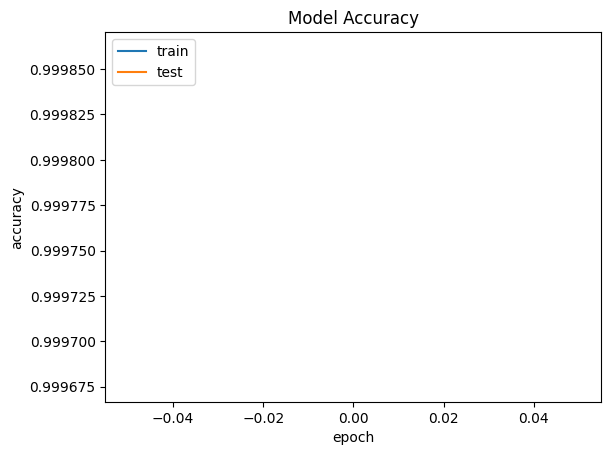

In [42]:
# plot of accuracy
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()


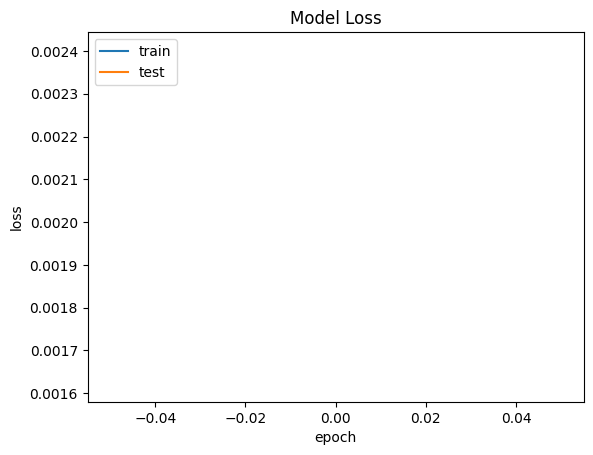

In [43]:
# plot of loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()